## AutoGen (AG2) and its Key Elements

- **Objectives**
    - AG2's Core agent concepts
    - Configure AG2 with an LLM
    - Run Agents with distinct roles and human input modes
    - Orchestrate agents using collboration patterns

- **Features**
    - Open-source frameworks for building AI agents
    - Multi-agent collboration to solve complex problem
        - agents like **Research analyst** and **createive writers** works in collboration to solve complex 
    - Provider-agnostic design that works with LLMs
        - works with various provides like Deepseek, Groq, etc
    - Human integration to support human-in-the-loop workflows
    - Robust error handling and scalability features

    ```python
    pip install ag2[openai]
    # openai files

    from autogen import ConversableGent, AssistantAgent, UserProxyAgent
    from autogen import GroupChat, GroupChatManager
    from autogen.llm_config import LLMConfig

    #LLM configuration
    ## Configure language model and connection settings
    llm_config = LLMConfig(api_type="openai", model="gpt-4o-mini")
    ```

### AG2 Architecture
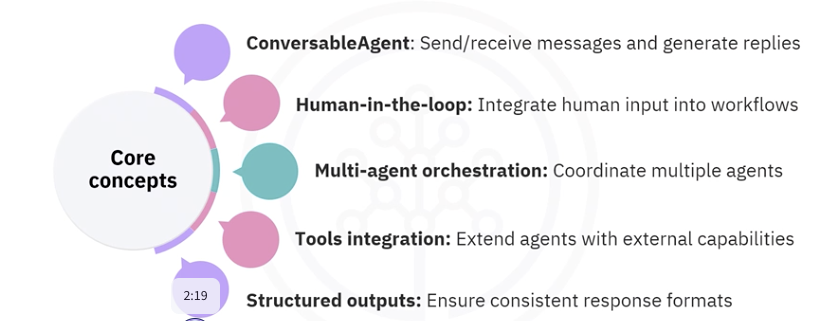

### ConversableAgent
- Fundamental building block of AG2
- Inherited by all ther agent types
- code example of student and tutor agent
```python
with llm_config:
    # student agent
    student = ConversableAgent(
        name="student",
        system_message="You are a curious student who asks clear questions",
        human_input_mode="NEVER" # the agent runs autonomously
    )

    # tutor agent
    tutor = ConversableAgent(
        name="tutor",
        system_message="You are a helpful tutor with clear explanations",
        human_input_mode="NEVER"
    )

#initiate_chat to start converation
chat_result = student.initiate_chat(
    recipient=tutor,
    message="Can you explain what a neural network is?",
    max_turns=2, #maximum iterations, prevent infinite loops
    summary_method="reflection_with_llm" #to generate a summary based on the full conversaation
)

print("Final Summary")
print(chat_result.summary)
```

### Benifits of Multi-Agent Approch
- Yields better results
- Simulate natural intractive learning
    - question and aswering
- Structured resoning through role-based collaboration
- Higher quality outputs form speciliye perspectives
- Context-rich answers from distributed resoning
- Scalable to Complex 

### Built-in agent types
- AssitantAgent
    - Handles Problem-solving
    - Generates code
- UserProxyAgent
    - Handles code execution
    - Provides feedback

- Example (AssistantAgent and UserProxyAgent working tougther)
```python
# create code writing agent
assistant = AssistantAgent(
     name="assistent",
    system_message="Helpful assistent who writes clear python code"
)

# create code-executing user proxy
user_proxy = UserProxyAgent(
    name="user_proxy",
    human_input_mode+"NEVER",
    max_consecutive_auto_reply=5, #to prevent infinite loops
    code_execution_config={
        "executor"=LocalCommandLineCodeExecutor(
            work_dir="coding"
        )
    }
)

# Execute agent communication
user_proxy.initiate_chat(
    recipient=assitant,
    message="Plot a sine wave using matlpotlib and save as sine_wave.png"
)
```

### Human-in-the-loop
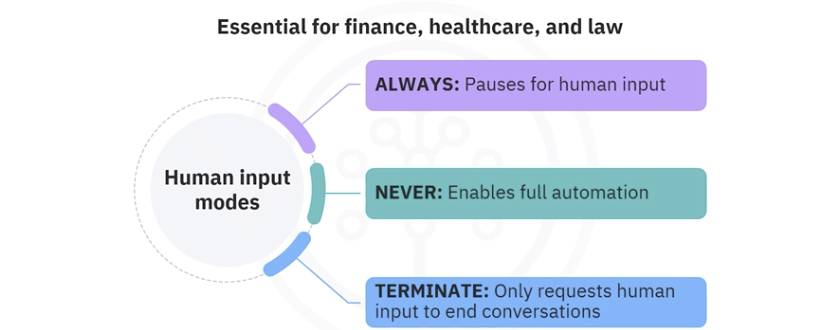
- UserProxyAgent
    - Default to human oversight
    - Ideal for AI-assisted workflwos with human contorl

```python
# Bug triage system with human oversigth
triage_system_message="""
You are a bug triage assistemt. For each bug report:
- Urgent issues(crash, secuirty, data loss): escalate and ask for confirmation
- Minor issues (cosmetic, typos): suggest closing but ask for review
- Oterwise: classify as medium priority and ask for review
"""

triage_bot = ConversableAgent(
    name="triage_bot",
    system_message=triage_system_message,
    llm_config=llm_config
)

human = ConversableAgent(
    name="human",
    human_input_mode="ALWAYS" # Human review each decision
)
```

### Multi-Agent Orchestration
- Assign specific roles
    - Enable agents to build on each other's outputs using
        - Two-agent chat: simple task exchange
        - Grouop chat: Diverse, multi-purpose discussions
        - Sequential chat: Step-by-step refinement
        - Nested chat: Reusable sub-conversations
- Incorporate human oversight at key discussion points
    - Keep complex systems organized, scalable, and manageable

- **GroupChat** and **GroupChatManager**
```python
# GroupChat defines participant and speaker strategy
groupchat = GroupChat(
    agents=[teacher, planner, reviewer],
    speaker_selection_method="auto" # LLM select next speaker
)

# GroupChatManager handles conversation flow
manager = GroupChatManager(
    name="group_manager",

)
```
- 4 speaker selection method
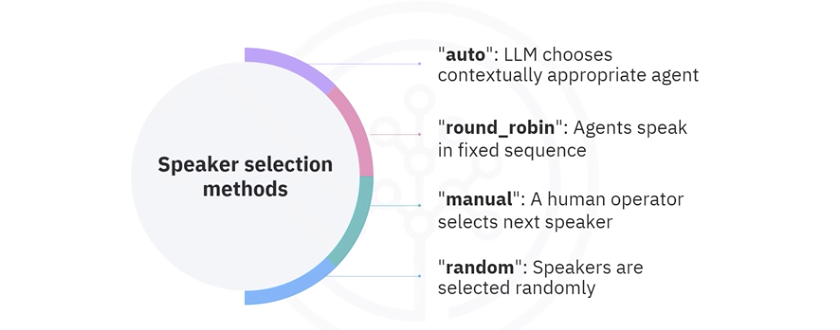

```python
lesson_planner = ConversableAgent(
    name="planner_agent",
    system_message="Create lession plans for 4th graders",
    description="Make lession plans"
)

lession_reviewer = ConversableAgent(
    name="reviewer_agent",
    system_message="Review plans and suggest upto 3 brief edits",
    description="Review lession plans and suggest edits"
)

teacher = ConversableAgent(
    name="teacher_agent",
    system_message="Suggest topics and reply DONE when satisfied",
    is_termination_msg=lambda x: "Done" in x.get("content", "").upper()
)

# configure the group chat with automatic speaker selection
groupchat = GroupChat(
    agents=[teacher, lession_planner, lession_reviewer],
    speaker_selection_method="auto" #Use AutoPattern
    # the system automatically select the person who select next
)

manager = GroupChatManager(
    name="group_manager",
    group_chat=groupchat,
    llm_config=llm_config
)

# Start with a short initial rpompt to keep tokens low
teacher.initiate_chat(
    recipient=manager,
    message="Make a simple lession about the moon.",
    max_turns=6, #Limit total rounds (eg, 2 per agent max)
    summary_mehtod="reflection_with_llm"
)
```

### Summary
- AG2 is an open-source framework for building intelligent AI agents that collaborate through structured, role-based interactions.
- AG2's core concepts, like ConversableAgent, human-in-the-loop, tools integration, and multi-agent orchestration, enable flexible, role-based collaboration.
- Agents are configured with LLM settings and system messages to define behavior, roles, and communication flow s for specilized tasks.
- Huam-in-the-loop modes provide orversight option ranging from full automation to manaual approval at key checkpoints.
- Multi-agent orchestration patterns, such as group chat and sequential flows, coordiate multiple agens to solve complex problems interactively.